# Figure 5 — Adhesion decoupling analysis

Examines how NB-NB adhesion strength (J=50/40/20) and relative-rotation mode
(off / mu=0 / mu=45 / mu=90) interact to shape NB spatial clustering.
mudmut VCV=1, VOL-ABM and VOL-PDE, 50 runs per condition.

- **A** — adhesion main effect: spatial metrics at baseline (relrot=off)
- **B** — adhesion main effect: example lineages (VOL-ABM and VOL-PDE)
- **C** — relative rotation sweep: metrics vs relrot mode, colored by adhesion
- **D** — relative rotation sweep: example lineages (3 J × 4 relrot, both dynamics)
- **E** — NB connectivity heatmap (fraction of runs with all NBs connected)
- **F** — connectivity example lineages (supplement candidate)


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


def find_repo_root(start: Path | None = None) -> Path:
    path = Path.cwd() if start is None else Path(start).resolve()
    for candidate in [path, *path.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "npa").exists():
            return candidate
    raise RuntimeError("Could not locate repo root from the current working directory.")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

from npa.sim_viz import load_raw_snapshot_full, render_raw

FIG_DIR = REPO_ROOT / "docs" / "tex_draft" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

_style_dir = str(REPO_ROOT / "docs" / "tex_draft")
if _style_dir not in sys.path:
    sys.path.insert(0, _style_dir)
from _style import RCPARAMS as _RCPARAMS, FONT_SIZE_TITLE, FONT_SIZE_LABEL
mpl.rcParams.update(_RCPARAMS)

print(f"Repo root: {REPO_ROOT}")
print(f"Output dir: {FIG_DIR}")


Repo root: /Users/skjannetty/bagherilab/neurogen-plane-rotation-analysis
Output dir: /Users/skjannetty/bagherilab/neurogen-plane-rotation-analysis/docs/tex_draft/figures


In [2]:
PROC_DIR = REPO_ROOT / "data" / "sim" / "processed_decoupling_adhesion"

run_idx = pd.read_csv(PROC_DIR / "sim_run_index.csv", dtype=str)
run_idx["npz_row"] = run_idx["npz_row"].astype(int)

exp_df  = pd.read_csv(PROC_DIR / "nb_exposure_metrics.csv")
conn_df = pd.read_csv(PROC_DIR / "nb_connectivity_metrics.csv")

_BOOL_MAP = {"True": True, "False": False, True: True, False: False}
for df in [exp_df, conn_df]:
    df["adhesion"]  = df["adhesion"].astype(int)
    df["div_stdev"] = df["div_stdev"].astype(int)
    df["relrot"]    = df["relrot"].map(_BOOL_MAP)
    df["run_id"]    = df["run_id"].astype(str)
conn_df["nb_connected"] = conn_df["nb_connected"].map(_BOOL_MAP)


def _relrot_label(row) -> str:
    if not row["relrot"]:
        return "off"
    m = row["relrot_mean"]
    return f"mu={int(m)}" if not pd.isna(m) else "mu=?"


for df in [exp_df, conn_df]:
    df["relrot_label"] = df.apply(_relrot_label, axis=1)

all_df = (
    exp_df[["condition", "sim_id", "run_id", "adhesion", "div_stdev",
            "relrot", "relrot_mean", "relrot_label",
            "critical_volume_mode", "regulatory_dynamic", "exposed_frac"]]
    .merge(conn_df[["condition", "sim_id", "run_id", "nb_connected"]],
           on=["condition", "sim_id", "run_id"], how="left")
)

print("Combined df shape:", all_df.shape)
print("Adhesion levels:", sorted(all_df["adhesion"].unique()))
print("Relrot labels:", sorted(all_df["relrot_label"].unique()))
print("Regulatory dynamics:", sorted(all_df["regulatory_dynamic"].unique()))


Combined df shape: (1200, 12)
Adhesion levels: [np.int64(20), np.int64(40), np.int64(50)]
Relrot labels: ['mu=0', 'mu=45', 'mu=90', 'off']
Regulatory dynamics: ['VOL-ABM', 'VOL-PDE']


In [3]:
# Okabe-Ito colorblind-friendly palette (no red, no blue-red confusion)
ADH_ORDER   = [50, 40, 20]
ADH_COLORS  = {50: "#E69F00", 40: "#56B4E9", 20: "#009E73"}
ADH_LABELS  = {50: "J=50\n(no diff.)", 40: "J=40\n(baseline)", 20: "J=20\n(strong)"}
ADH_LEGEND  = {50: "J=50 (no diff.)", 40: "J=40 (baseline)", 20: "J=20 (strong)"}
RELROT_ORDER  = ["off", "mu=0", "mu=45", "mu=90"]
RELROT_LABELS = {"off": "off", "mu=0": "mu=0°", "mu=45": "mu=45°", "mu=90": "mu=90°"}
REG_DYN_ORDER = ["VOL-ABM", "VOL-PDE"]
SIM_ID_MAP    = {"VOL-ABM": "vcv1_vol_abm", "VOL-PDE": "vcv1_vol_pde"}

SPATIAL_METRICS = ["exposed_frac"]
METRIC_LABELS = {
    "exposed_frac": "NB exposed frac",
    "nb_connected": "Fraction connected",
}


def _cond_name(adh: int, relrot_label: str) -> str:
    base = f"mudmut_adh{adh}_divMean0Stdev50"
    if relrot_label == "off":
        return base
    mu = int(relrot_label.split("=")[1])
    return f"{base}_relrotMean{mu}"


def content_bbox(arr: np.ndarray, pad: int = 6) -> tuple[int, int, int, int]:
    occ = arr.any(axis=-1) if arr.ndim == 3 else arr > 0
    ys, xs = np.where(occ)
    if len(xs) == 0:
        h, w = arr.shape[:2]
        return 0, 0, h, w
    y0 = max(int(ys.min()) - pad, 0)
    y1 = min(int(ys.max()) + pad + 1, arr.shape[0])
    x0 = max(int(xs.min()) - pad, 0)
    x1 = min(int(xs.max()) + pad + 1, arr.shape[1])
    return y0, x0, y1, x1


def uniform_crop_size(geo_list: list[np.ndarray], pad: int = 6) -> int:
    max_dim = 0
    for geo in geo_list:
        y0, x0, y1, x1 = content_bbox(geo, pad=pad)
        max_dim = max(max_dim, y1 - y0, x1 - x0)
    return max_dim


def crop_centered(arr: np.ndarray, target_size: int) -> np.ndarray:
    occ = arr.any(axis=-1) if arr.ndim == 3 else arr > 0
    ys, xs = np.where(occ)
    if len(xs) == 0:
        cy, cx = arr.shape[0] // 2, arr.shape[1] // 2
    else:
        cy = (int(ys.min()) + int(ys.max())) // 2
        cx = (int(xs.min()) + int(xs.max())) // 2
    half = target_size // 2
    y0 = max(0, min(cy - half, arr.shape[0] - target_size))
    x0 = max(0, min(cx - half, arr.shape[1] - target_size))
    if arr.ndim == 3:
        return arr[y0:y0 + target_size, x0:x0 + target_size, :]
    return arr[y0:y0 + target_size, x0:x0 + target_size]


def _load_median_run(cond: str, sim_id: str, metric_df: pd.DataFrame,
                      metric_col: str) -> tuple[np.ndarray | None, np.ndarray | None, float]:
    # Returns (geo_raw, lmap, median_value) for the run closest to metric median.
    sub = metric_df[(metric_df["condition"] == cond) & (metric_df["sim_id"] == sim_id)]
    if sub.empty:
        return None, None, np.nan
    med = float(sub[metric_col].median())
    best_run = int(sub.loc[(sub[metric_col] - med).abs().idxmin(), "run_id"])
    run_str = str(best_run).zfill(4)
    match = run_idx[
        (run_idx["condition"] == cond) &
        (run_idx["sim_id"] == sim_id) &
        (run_idx["run_id"] == run_str)
    ]
    if match.empty:
        return None, None, np.nan
    r = match.iloc[0]
    geo_raw, lmap = load_raw_snapshot_full(
        REPO_ROOT / r["cells_path"], REPO_ROOT / r["locs_path"]
    )
    return geo_raw, lmap, med


def style_axis(ax: plt.Axes) -> None:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", color="#d0d0d0", linewidth=0.6, alpha=0.5)
    ax.tick_params(axis="x", length=0)


## Panel A — Adhesion main effect (metrics)

Spatial metrics at baseline (relrot=off) for J=50/40/20.
Rows = metric (NB exposed frac, Fraction connected); columns = regulatory dynamic.


saved figure5_adhesion_main_effect


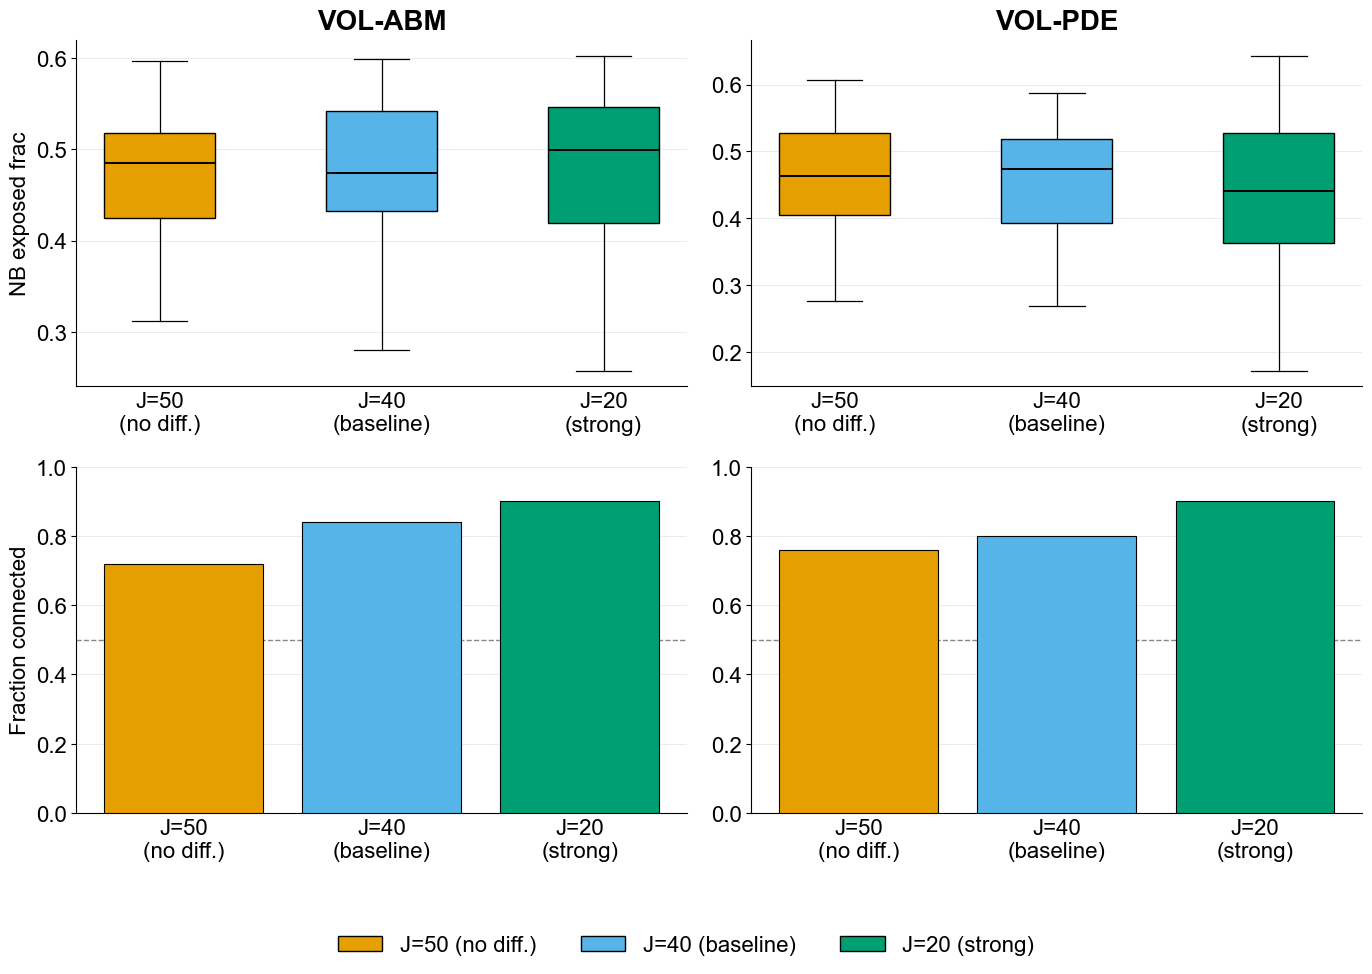

In [4]:
def panel_a() -> plt.Figure:
    baseline = all_df[all_df["relrot_label"] == "off"]
    plot_metrics = SPATIAL_METRICS + ["nb_connected"]

    fig, axes = plt.subplots(
        len(plot_metrics), len(REG_DYN_ORDER),
        figsize=(7.0 * len(REG_DYN_ORDER), 5.0 * len(plot_metrics)),
        squeeze=False,
    )

    for ri, metric in enumerate(plot_metrics):
        for ci, reg_dyn in enumerate(REG_DYN_ORDER):
            ax = axes[ri, ci]
            sub = baseline[baseline["regulatory_dynamic"] == reg_dyn]
            if metric == "nb_connected":
                fracs = [float(sub[sub["adhesion"] == adh]["nb_connected"].mean())
                         for adh in ADH_ORDER]
                ax.bar(range(len(ADH_ORDER)), fracs,
                       color=[ADH_COLORS[a] for a in ADH_ORDER],
                       edgecolor="black", linewidth=0.8, zorder=3)
                ax.set_ylim(0, 1)
                ax.axhline(0.5, color="#888888", linestyle="--", linewidth=1, zorder=2)
            else:
                for ti, adh in enumerate(ADH_ORDER):
                    runs = sub[sub["adhesion"] == adh][metric].dropna()
                    if runs.empty:
                        continue
                    ax.boxplot(
                        [runs], positions=[ti], widths=0.5,
                        patch_artist=True, showfliers=False,
                        medianprops={"color": "black", "linewidth": 1.4},
                        boxprops={"facecolor": ADH_COLORS[adh], "edgecolor": "black", "linewidth": 1.0},
                        whiskerprops={"color": "black", "linewidth": 0.9},
                        capprops={"color": "black", "linewidth": 0.9},
                        manage_ticks=False, zorder=3,
                    )
            ax.set_xticks(range(len(ADH_ORDER)))
            ax.set_xticklabels([ADH_LABELS[a] for a in ADH_ORDER])
            if ri == 0:
                ax.set_title(reg_dyn, fontsize=FONT_SIZE_TITLE, pad=8, fontweight="bold")
            if ci == 0:
                ax.set_ylabel(METRIC_LABELS[metric], fontsize=FONT_SIZE_LABEL)
            style_axis(ax)

    handles = [Patch(facecolor=ADH_COLORS[a], edgecolor="black", label=ADH_LEGEND[a])
               for a in ADH_ORDER]
    fig.tight_layout(rect=[0, 0.10, 1, 1])
    fig.legend(handles=handles, loc="lower center", ncol=3, frameon=False,
               fontsize=FONT_SIZE_LABEL, bbox_to_anchor=(0.5, 0.01))
    return fig


fig_a = panel_a()
fig_a.savefig(FIG_DIR / "figure5_adhesion_main_effect.png", bbox_inches="tight", facecolor="white")
fig_a.savefig(FIG_DIR / "figure5_adhesion_main_effect.pdf", bbox_inches="tight", facecolor="white")
print("saved figure5_adhesion_main_effect")
plt.show()


## Panel B — Adhesion main effect: example lineages

Rows = regulatory dynamic (VOL-ABM, VOL-PDE); columns = adhesion J.
Run selected at median `exposed_frac`. Uniform crop across all images.


panel B uniform crop: 107px


saved figure5_adhesion_main_effect_lineages


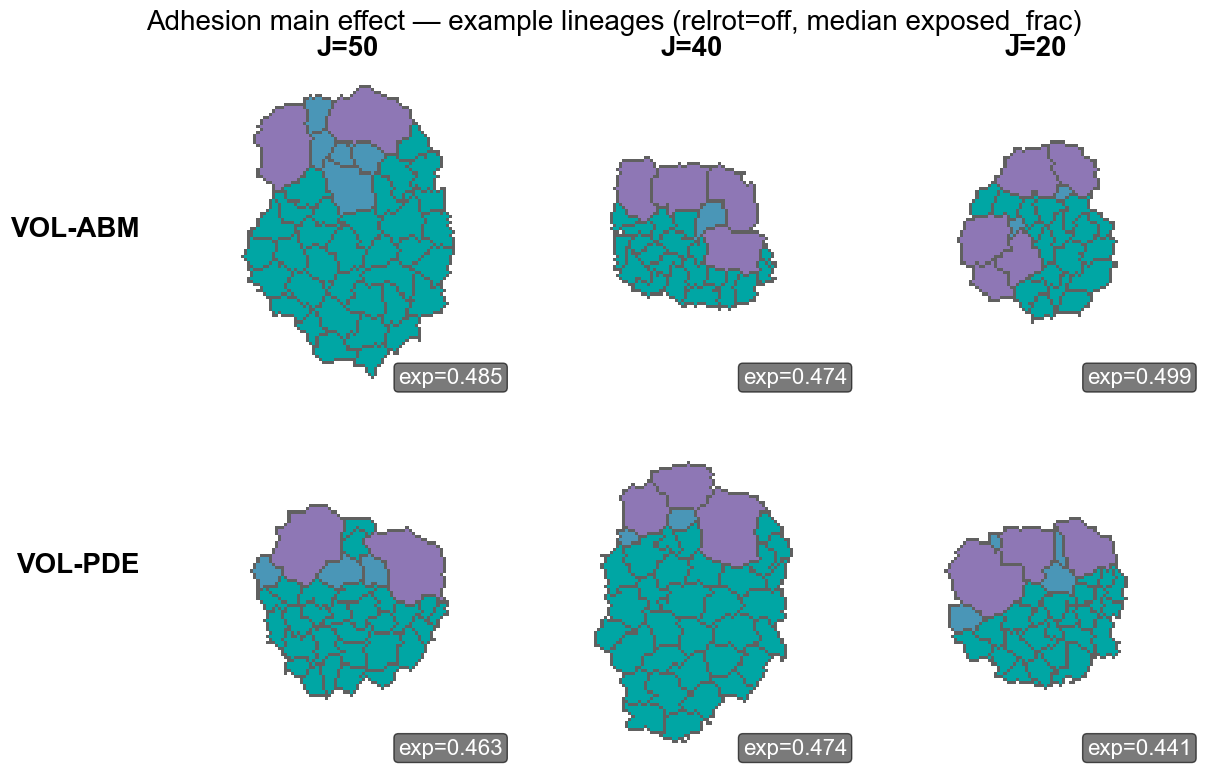

In [5]:
def panel_b() -> plt.Figure:
    # First pass: load all runs
    snapshots: dict[tuple, tuple] = {}
    for reg_dyn in REG_DYN_ORDER:
        sim_id = SIM_ID_MAP[reg_dyn]
        for adh in ADH_ORDER:
            cond = _cond_name(adh, "off")
            geo, lmap, med = _load_median_run(cond, sim_id, exp_df, "exposed_frac")
            snapshots[(reg_dyn, adh)] = (geo, lmap, med)

    all_geos = [v[0] for v in snapshots.values() if v[0] is not None]
    target_size = uniform_crop_size(all_geos, pad=6)
    print(f"panel B uniform crop: {target_size}px")

    fig, axes = plt.subplots(
        len(REG_DYN_ORDER), len(ADH_ORDER),
        figsize=(4.0 * len(ADH_ORDER), 4.0 * len(REG_DYN_ORDER)),
        squeeze=False,
    )

    for ri, reg_dyn in enumerate(REG_DYN_ORDER):
        for ci, adh in enumerate(ADH_ORDER):
            ax = axes[ri, ci]
            geo, lmap, med = snapshots[(reg_dyn, adh)]
            if geo is None:
                ax.text(0.5, 0.5, "no data", ha="center", va="center",
                        transform=ax.transAxes)
                ax.axis("off")
                continue
            render_raw(crop_centered(geo, target_size),
                       label_map=crop_centered(lmap, target_size), ax=ax, title="")
            ax.axis("off")
            if ri == 0:
                ax.set_title(f"J={adh}", fontsize=FONT_SIZE_TITLE, pad=8, fontweight="bold")
            if not np.isnan(med):
                ax.text(0.97, 0.03, f"exp={med:.3f}", transform=ax.transAxes,
                        fontsize=FONT_SIZE_LABEL, va="bottom", ha="right", color="white",
                        bbox=dict(boxstyle="round,pad=0.2", facecolor="#333333", alpha=0.65))

        bbox = axes[ri, 0].get_position()
        fig.text(bbox.x0 - 0.02, (bbox.y0 + bbox.y1) / 2, reg_dyn,
                 ha="right", va="center", fontsize=FONT_SIZE_TITLE, fontweight="bold")

    fig.suptitle("Adhesion main effect — example lineages (relrot=off, median exposed_frac)",
                  fontsize=FONT_SIZE_TITLE)
    fig.subplots_adjust(left=0.14, right=0.99, top=0.92, bottom=0.02, wspace=0.04, hspace=0.06)
    return fig


fig_b = panel_b()
fig_b.savefig(FIG_DIR / "figure5_adhesion_main_effect_lineages.png", bbox_inches="tight", facecolor="white")
fig_b.savefig(FIG_DIR / "figure5_adhesion_main_effect_lineages.pdf", bbox_inches="tight", facecolor="white")
print("saved figure5_adhesion_main_effect_lineages")
plt.show()


## Panel C — Relative rotation sweep (metrics)

Spatial metrics vs relrot mode (off / mu=0 / mu=45 / mu=90).
Lines colored by adhesion strength. Rows = metric (NB exposed frac, Fraction connected); columns = regulatory dynamic.
Points = median; error bars = IQR/2. `nb_connected` = fraction of runs connected.


saved figure5_rotation_sweep


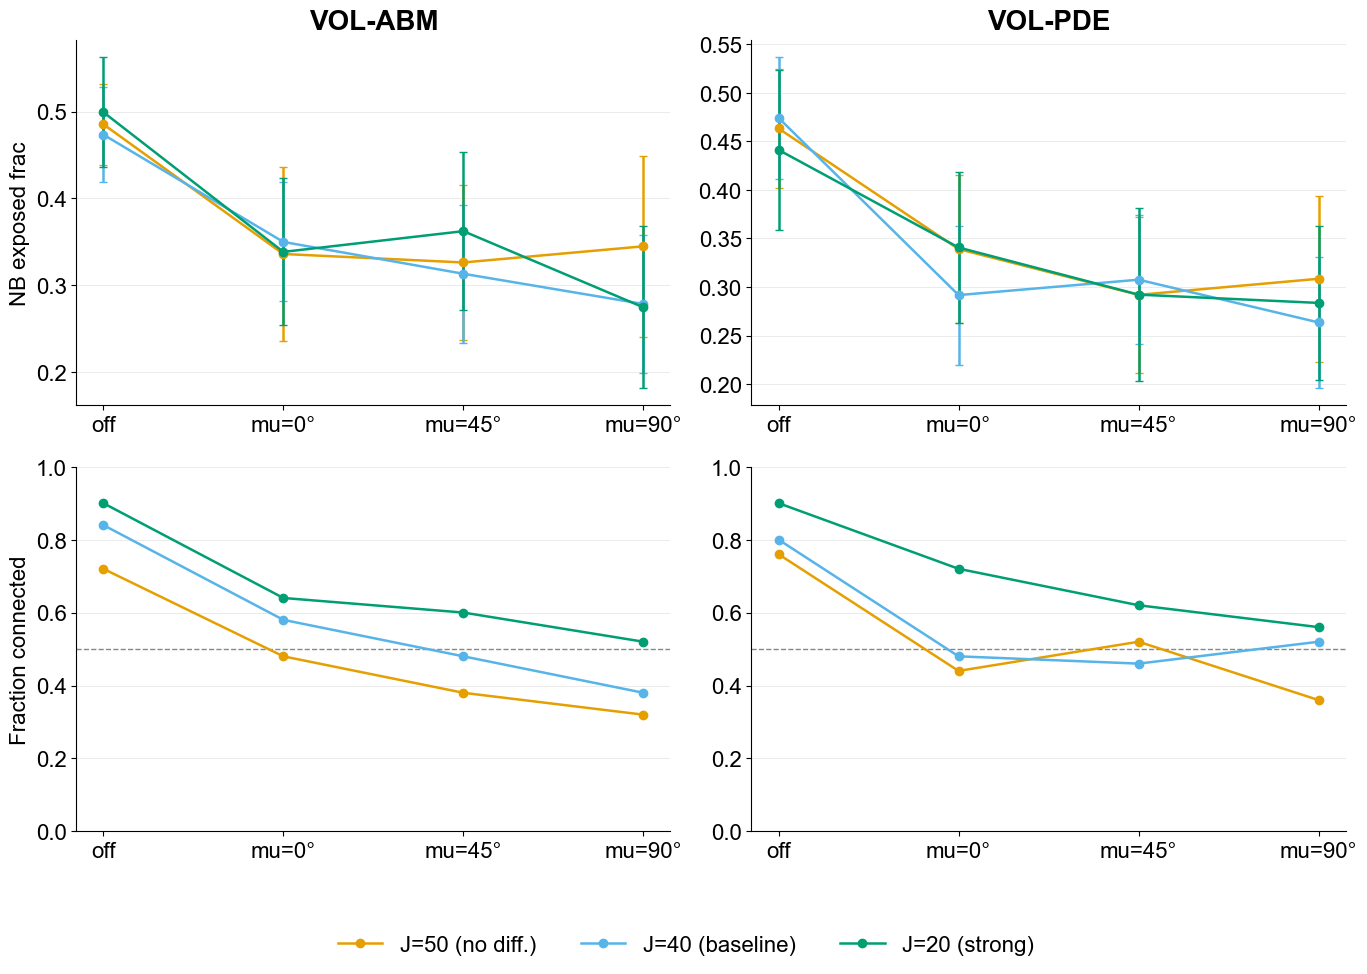

In [6]:
def panel_c() -> plt.Figure:
    plot_metrics = SPATIAL_METRICS + ["nb_connected"]
    x_pos = list(range(len(RELROT_ORDER)))
    x_labels = [RELROT_LABELS[r] for r in RELROT_ORDER]

    fig, axes = plt.subplots(
        len(plot_metrics), len(REG_DYN_ORDER),
        figsize=(7.0 * len(REG_DYN_ORDER), 5.0 * len(plot_metrics)),
        squeeze=False,
    )

    for ri, metric in enumerate(plot_metrics):
        for ci, reg_dyn in enumerate(REG_DYN_ORDER):
            ax = axes[ri, ci]
            sub = all_df[all_df["regulatory_dynamic"] == reg_dyn]
            for adh in ADH_ORDER:
                ys, errs = [], []
                for rl in RELROT_ORDER:
                    vals = sub[(sub["adhesion"] == adh) & (sub["relrot_label"] == rl)][metric].dropna()
                    if vals.empty:
                        ys.append(np.nan); errs.append(0.0)
                    elif metric == "nb_connected":
                        ys.append(float(vals.mean())); errs.append(0.0)
                    else:
                        ys.append(float(vals.median()))
                        errs.append((float(vals.quantile(0.75)) - float(vals.quantile(0.25))) / 2)
                kw = dict(color=ADH_COLORS[adh], marker="o", linewidth=1.8,
                          markersize=6, label=ADH_LEGEND[adh])
                if metric == "nb_connected":
                    ax.plot(x_pos, ys, **kw)
                else:
                    ax.errorbar(x_pos, ys, yerr=errs, capsize=3, **kw)

            if metric == "nb_connected":
                ax.set_ylim(0, 1)
                ax.axhline(0.5, color="#888888", linestyle="--", linewidth=1, zorder=1)

            ax.set_xticks(x_pos)
            ax.set_xticklabels(x_labels)
            if ri == 0:
                ax.set_title(reg_dyn, fontsize=FONT_SIZE_TITLE, pad=8, fontweight="bold")
            if ci == 0:
                ax.set_ylabel(METRIC_LABELS[metric], fontsize=FONT_SIZE_LABEL)
            ax.grid(axis="y", color="#d0d0d0", linewidth=0.6, alpha=0.5)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

    handles = [Line2D([0], [0], color=ADH_COLORS[a], marker="o",
                       linewidth=1.8, markersize=6, label=ADH_LEGEND[a])
               for a in ADH_ORDER]
    fig.tight_layout(rect=[0, 0.10, 1, 1])
    fig.legend(handles=handles, loc="lower center", ncol=3, frameon=False,
               fontsize=FONT_SIZE_LABEL, bbox_to_anchor=(0.5, 0.01))
    return fig


fig_c = panel_c()
fig_c.savefig(FIG_DIR / "figure5_rotation_sweep.png", bbox_inches="tight", facecolor="white")
fig_c.savefig(FIG_DIR / "figure5_rotation_sweep.pdf", bbox_inches="tight", facecolor="white")
print("saved figure5_rotation_sweep")
plt.show()


## Panel D — Relative rotation sweep: example lineages

6 × 4 grid: rows = (VOL-ABM J=50/40/20, VOL-PDE J=50/40/20), columns = relrot mode.
Run selected at median `exposed_frac`. Uniform crop across all images.


panel D uniform crop: 107px


saved figure5_rotation_sweep_lineages


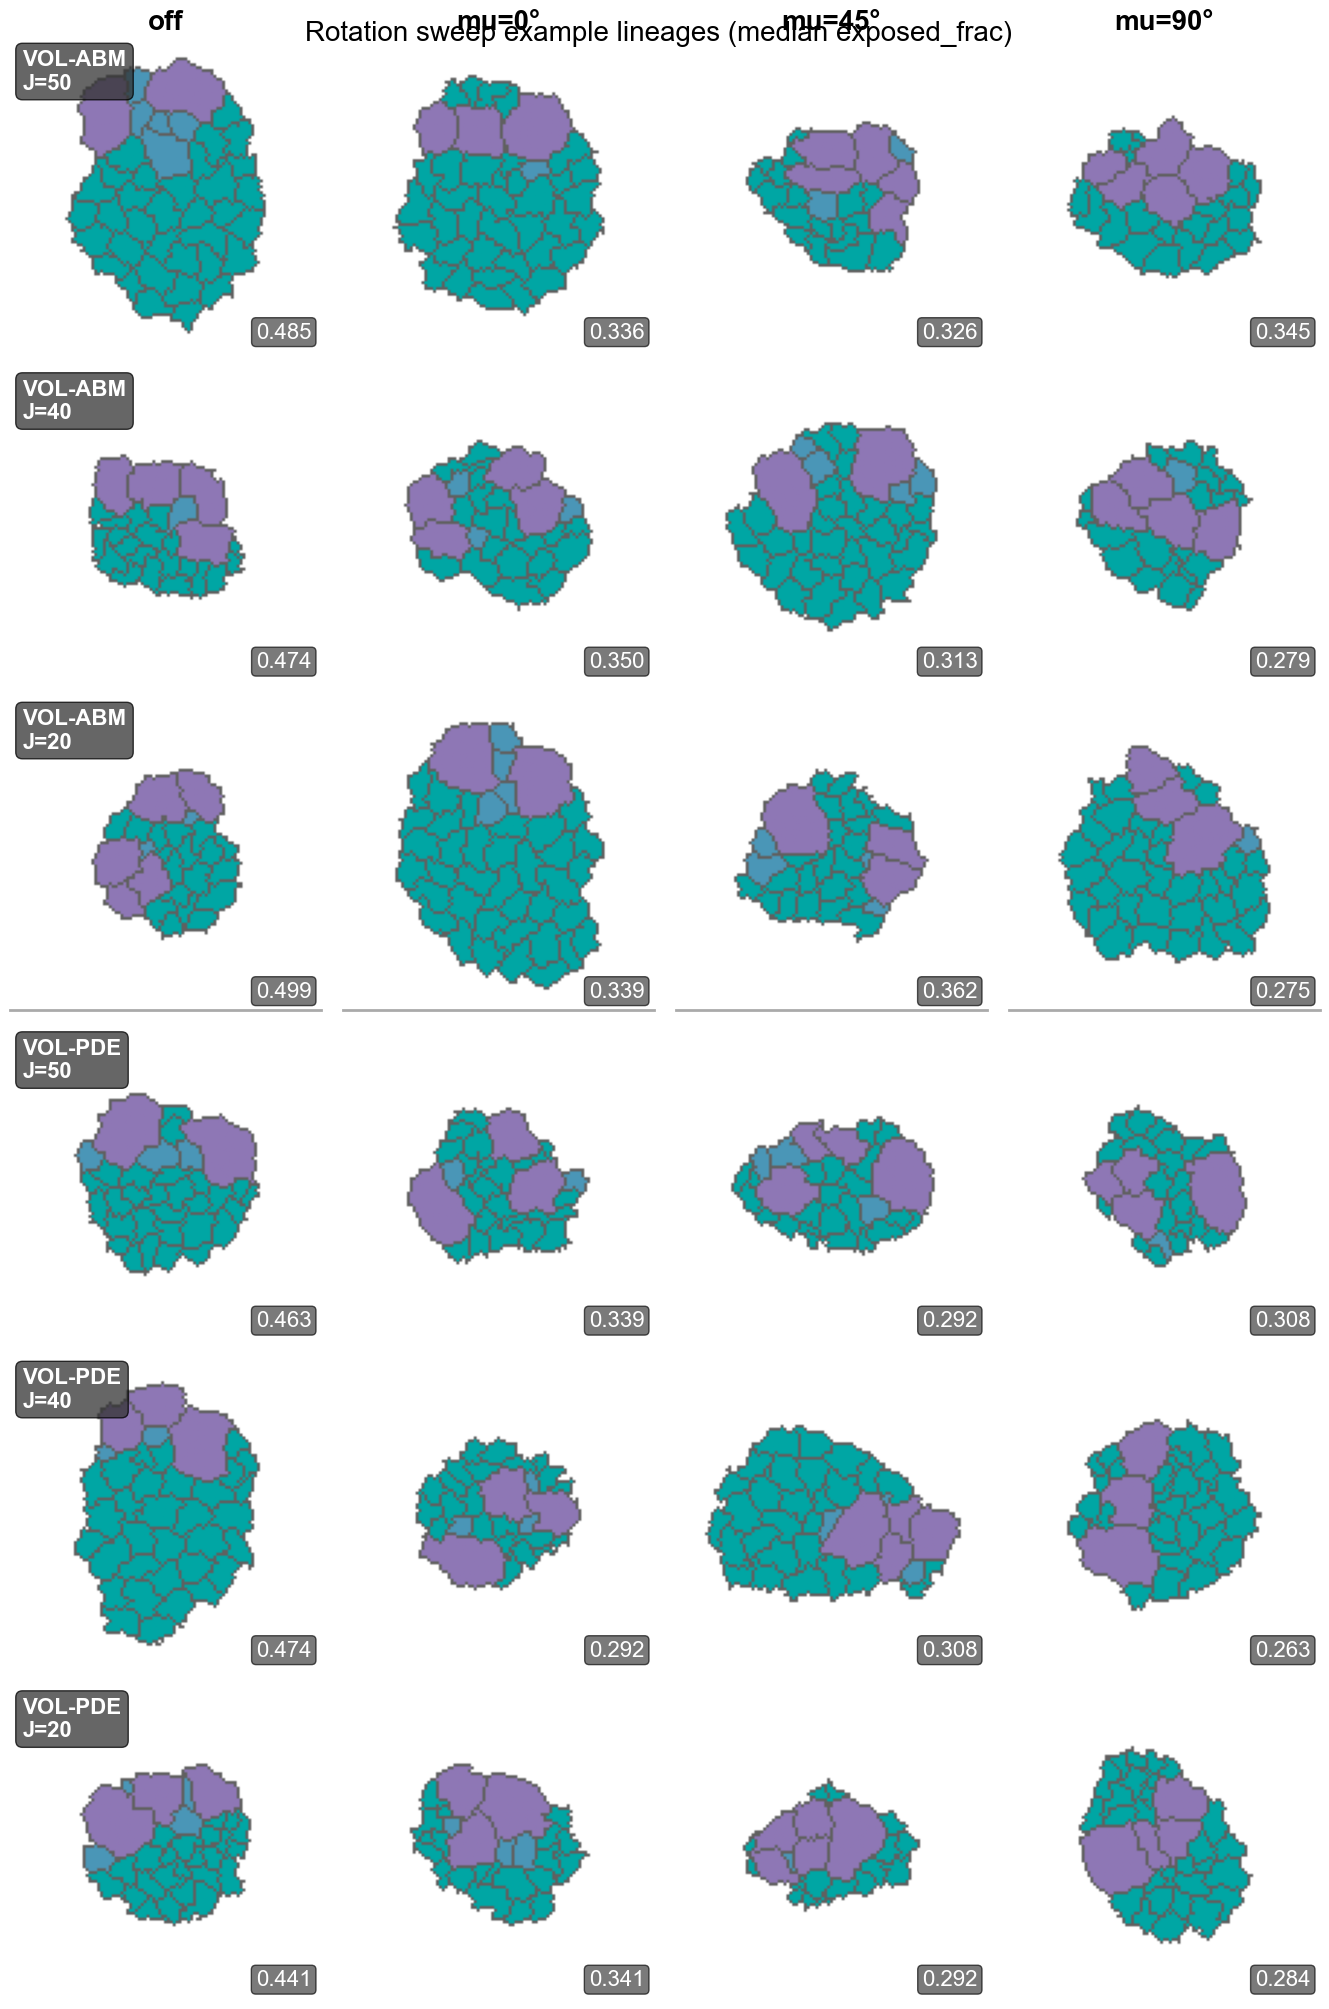

In [7]:
def panel_d() -> plt.Figure:
    # First pass: load all runs
    keys = [(reg, adh, rl) for reg in REG_DYN_ORDER
            for adh in ADH_ORDER for rl in RELROT_ORDER]
    snapshots: dict[tuple, tuple] = {}
    for reg_dyn, adh, rl in keys:
        cond = _cond_name(adh, rl)
        geo, lmap, med = _load_median_run(cond, SIM_ID_MAP[reg_dyn], exp_df, "exposed_frac")
        snapshots[(reg_dyn, adh, rl)] = (geo, lmap, med)

    all_geos = [v[0] for v in snapshots.values() if v[0] is not None]
    target_size = uniform_crop_size(all_geos, pad=6)
    print(f"panel D uniform crop: {target_size}px")

    n_rows = len(REG_DYN_ORDER) * len(ADH_ORDER)
    n_cols = len(RELROT_ORDER)
    fig, axes = plt.subplots(n_rows, n_cols,
                              figsize=(3.4 * n_cols, 3.4 * n_rows),
                              squeeze=False)

    for ri_reg, reg_dyn in enumerate(REG_DYN_ORDER):
        for ri_adh, adh in enumerate(ADH_ORDER):
            row = ri_reg * len(ADH_ORDER) + ri_adh
            for ci, rl in enumerate(RELROT_ORDER):
                ax = axes[row, ci]
                geo, lmap, med = snapshots[(reg_dyn, adh, rl)]
                if geo is None:
                    ax.text(0.5, 0.5, "no data", ha="center", va="center",
                            transform=ax.transAxes)
                    ax.axis("off")
                    continue
                render_raw(crop_centered(geo, target_size),
                           label_map=crop_centered(lmap, target_size), ax=ax, title="")
                ax.axis("off")
                if row == 0:
                    ax.set_title(RELROT_LABELS[rl], fontsize=FONT_SIZE_TITLE,
                                  pad=8, fontweight="bold")
                if ci == 0:
                    ax.text(0.04, 0.97, f"{reg_dyn}\nJ={adh}",
                            transform=ax.transAxes, fontsize=FONT_SIZE_LABEL,
                            fontweight="bold", va="top", ha="left", color="white",
                            bbox=dict(boxstyle="round,pad=0.3", facecolor="#333333", alpha=0.75))
                if not np.isnan(med):
                    ax.text(0.97, 0.03, f"{med:.3f}", transform=ax.transAxes,
                            fontsize=FONT_SIZE_LABEL, va="bottom", ha="right", color="white",
                            bbox=dict(boxstyle="round,pad=0.2", facecolor="#333333", alpha=0.65))

        # Separator line between VOL-ABM and VOL-PDE blocks
        if ri_reg < len(REG_DYN_ORDER) - 1:
            sep_row = (ri_reg + 1) * len(ADH_ORDER)
            for ci in range(n_cols):
                sep_ax = axes[sep_row - 1, ci]
                sep_ax.plot([0, 1], [0, 0], transform=sep_ax.transAxes,
                            color="#aaaaaa", linewidth=2, clip_on=False)

    fig.suptitle("Rotation sweep example lineages (median exposed_frac)",
                  fontsize=FONT_SIZE_TITLE)
    fig.subplots_adjust(left=0.02, right=0.99, top=0.97, bottom=0.01,
                         wspace=0.04, hspace=0.06)
    return fig


fig_d = panel_d()
fig_d.savefig(FIG_DIR / "figure5_rotation_sweep_lineages.png", bbox_inches="tight", facecolor="white")
fig_d.savefig(FIG_DIR / "figure5_rotation_sweep_lineages.pdf", bbox_inches="tight", facecolor="white")
print("saved figure5_rotation_sweep_lineages")
plt.show()


## Panel E — NB connectivity heatmap

Fraction of 50 runs where all NBs form one connected component.
Rows = adhesion J (50 / 40 / 20), columns = relrot mode.
Diverging colormap (PuOr_r) centered at 0.5.


saved figure5_connectivity_heatmap


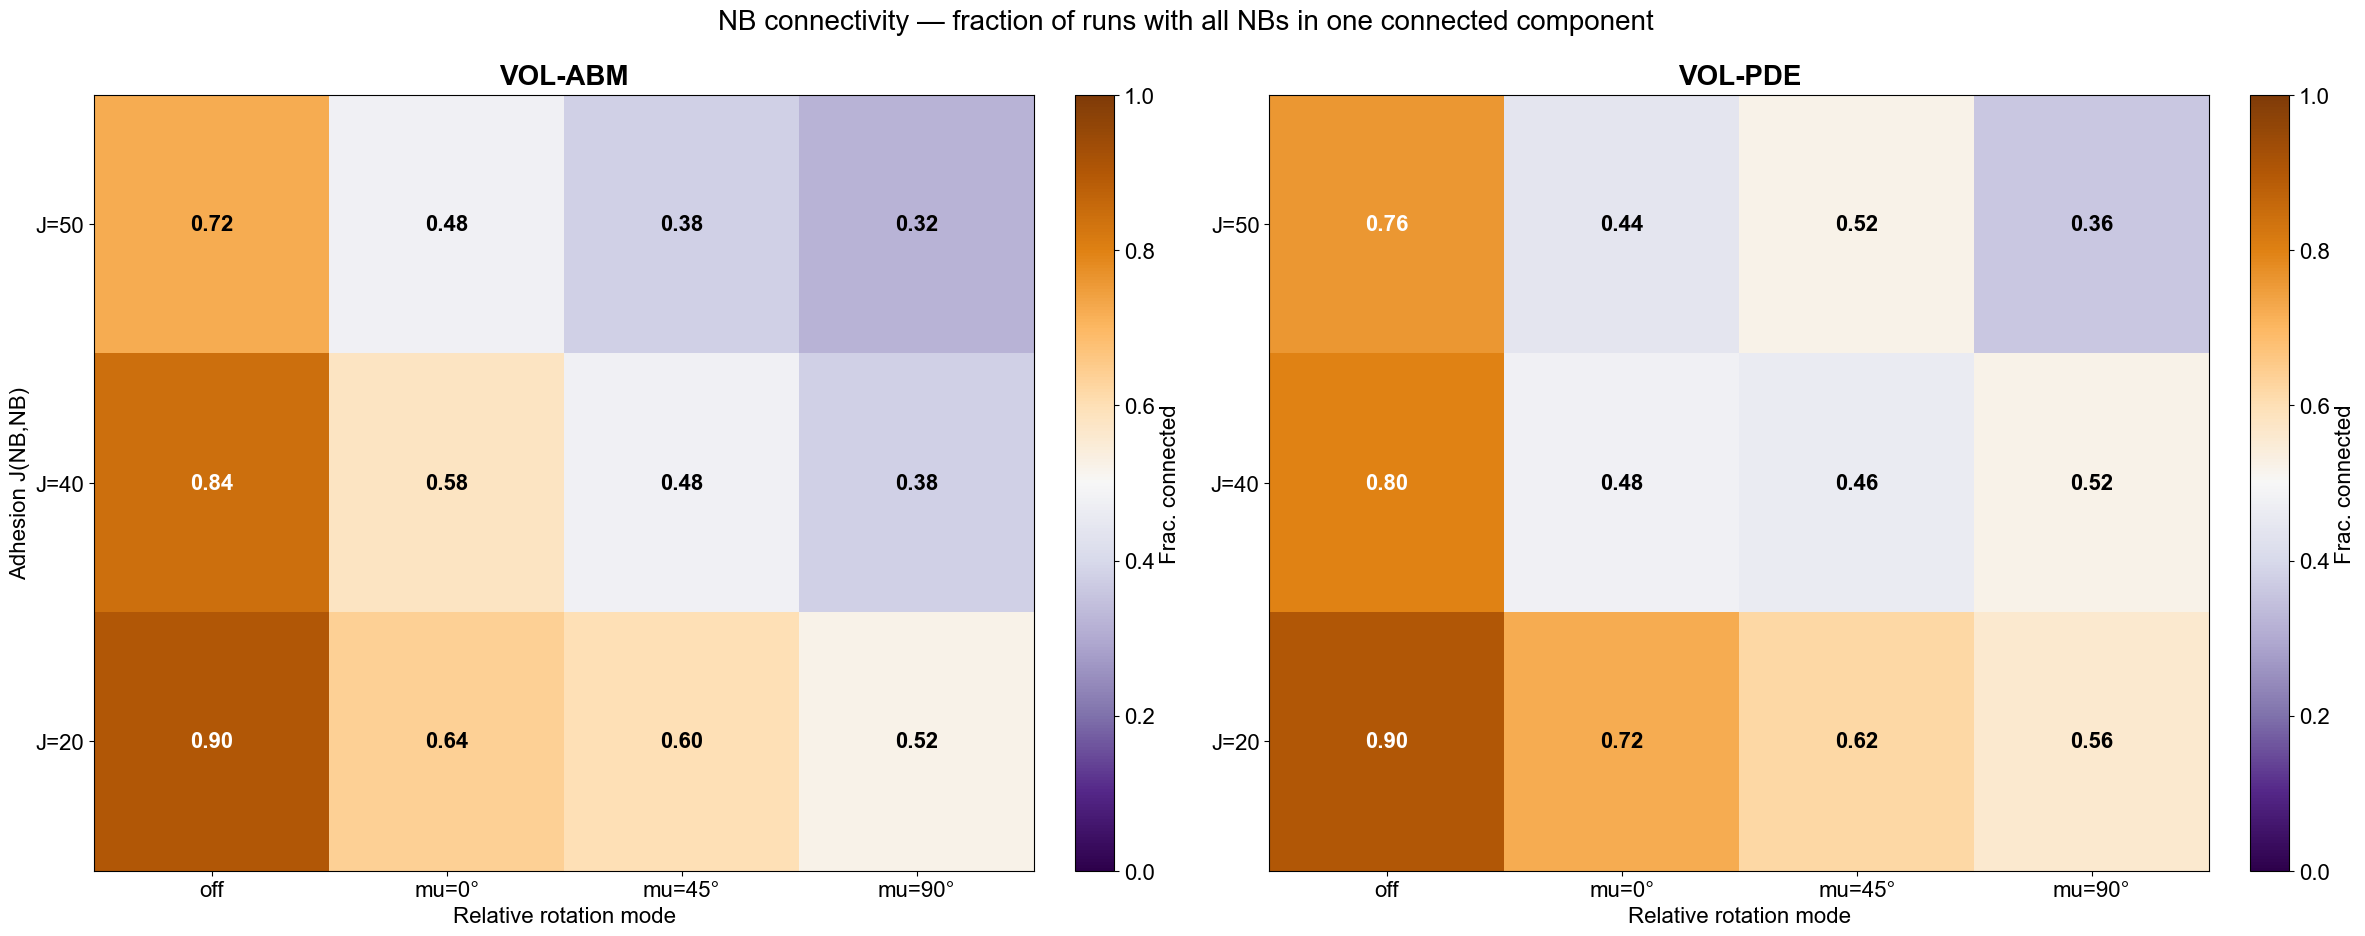

In [8]:
def panel_e() -> plt.Figure:
    norm = mcolors.TwoSlopeNorm(vmin=0.0, vcenter=0.5, vmax=1.0)

    fig, axes = plt.subplots(
        1, len(REG_DYN_ORDER),
        figsize=(6.0 * len(RELROT_ORDER), 3.2 * len(ADH_ORDER)),
        squeeze=False,
    )

    for ci, reg_dyn in enumerate(REG_DYN_ORDER):
        ax = axes[0, ci]
        sub = all_df[all_df["regulatory_dynamic"] == reg_dyn]

        mat = np.full((len(ADH_ORDER), len(RELROT_ORDER)), np.nan)
        for ai, adh in enumerate(ADH_ORDER):
            for rli, rl in enumerate(RELROT_ORDER):
                vals = sub[(sub["adhesion"] == adh) & (sub["relrot_label"] == rl)
                            ]["nb_connected"].dropna()
                if not vals.empty:
                    mat[ai, rli] = float(vals.mean())

        im = ax.imshow(mat, norm=norm, cmap="PuOr_r", aspect="auto")
        ax.set_xticks(range(len(RELROT_ORDER)))
        ax.set_xticklabels([RELROT_LABELS[r] for r in RELROT_ORDER])
        ax.set_yticks(range(len(ADH_ORDER)))
        ax.set_yticklabels([f"J={a}" for a in ADH_ORDER])
        ax.set_xlabel("Relative rotation mode")
        if ci == 0:
            ax.set_ylabel("Adhesion J(NB,NB)")
        ax.set_title(reg_dyn, fontsize=FONT_SIZE_TITLE, pad=8, fontweight="bold")

        for ai in range(len(ADH_ORDER)):
            for rli in range(len(RELROT_ORDER)):
                v = mat[ai, rli]
                if not np.isnan(v):
                    txt_color = "white" if abs(v - 0.5) > 0.25 else "black"
                    ax.text(rli, ai, f"{v:.2f}", ha="center", va="center",
                            fontsize=FONT_SIZE_LABEL, fontweight="bold", color=txt_color)

        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Frac. connected")

    fig.suptitle("NB connectivity — fraction of runs with all NBs in one connected component",
                  fontsize=FONT_SIZE_TITLE)
    fig.tight_layout()
    return fig


fig_e = panel_e()
fig_e.savefig(FIG_DIR / "figure5_connectivity_heatmap.png", bbox_inches="tight", facecolor="white")
fig_e.savefig(FIG_DIR / "figure5_connectivity_heatmap.pdf", bbox_inches="tight", facecolor="white")
print("saved figure5_connectivity_heatmap")
plt.show()


## Panel F — Connectivity heatmap: example lineages (supplement candidate)

6 × 4 grid: rows = (VOL-ABM J=50/40/20, VOL-PDE J=50/40/20), columns = relrot mode.
Run selected at median `exposed_frac`. Uniform crop across all images.


panel F uniform crop: 107px


saved figure5_connectivity_lineages


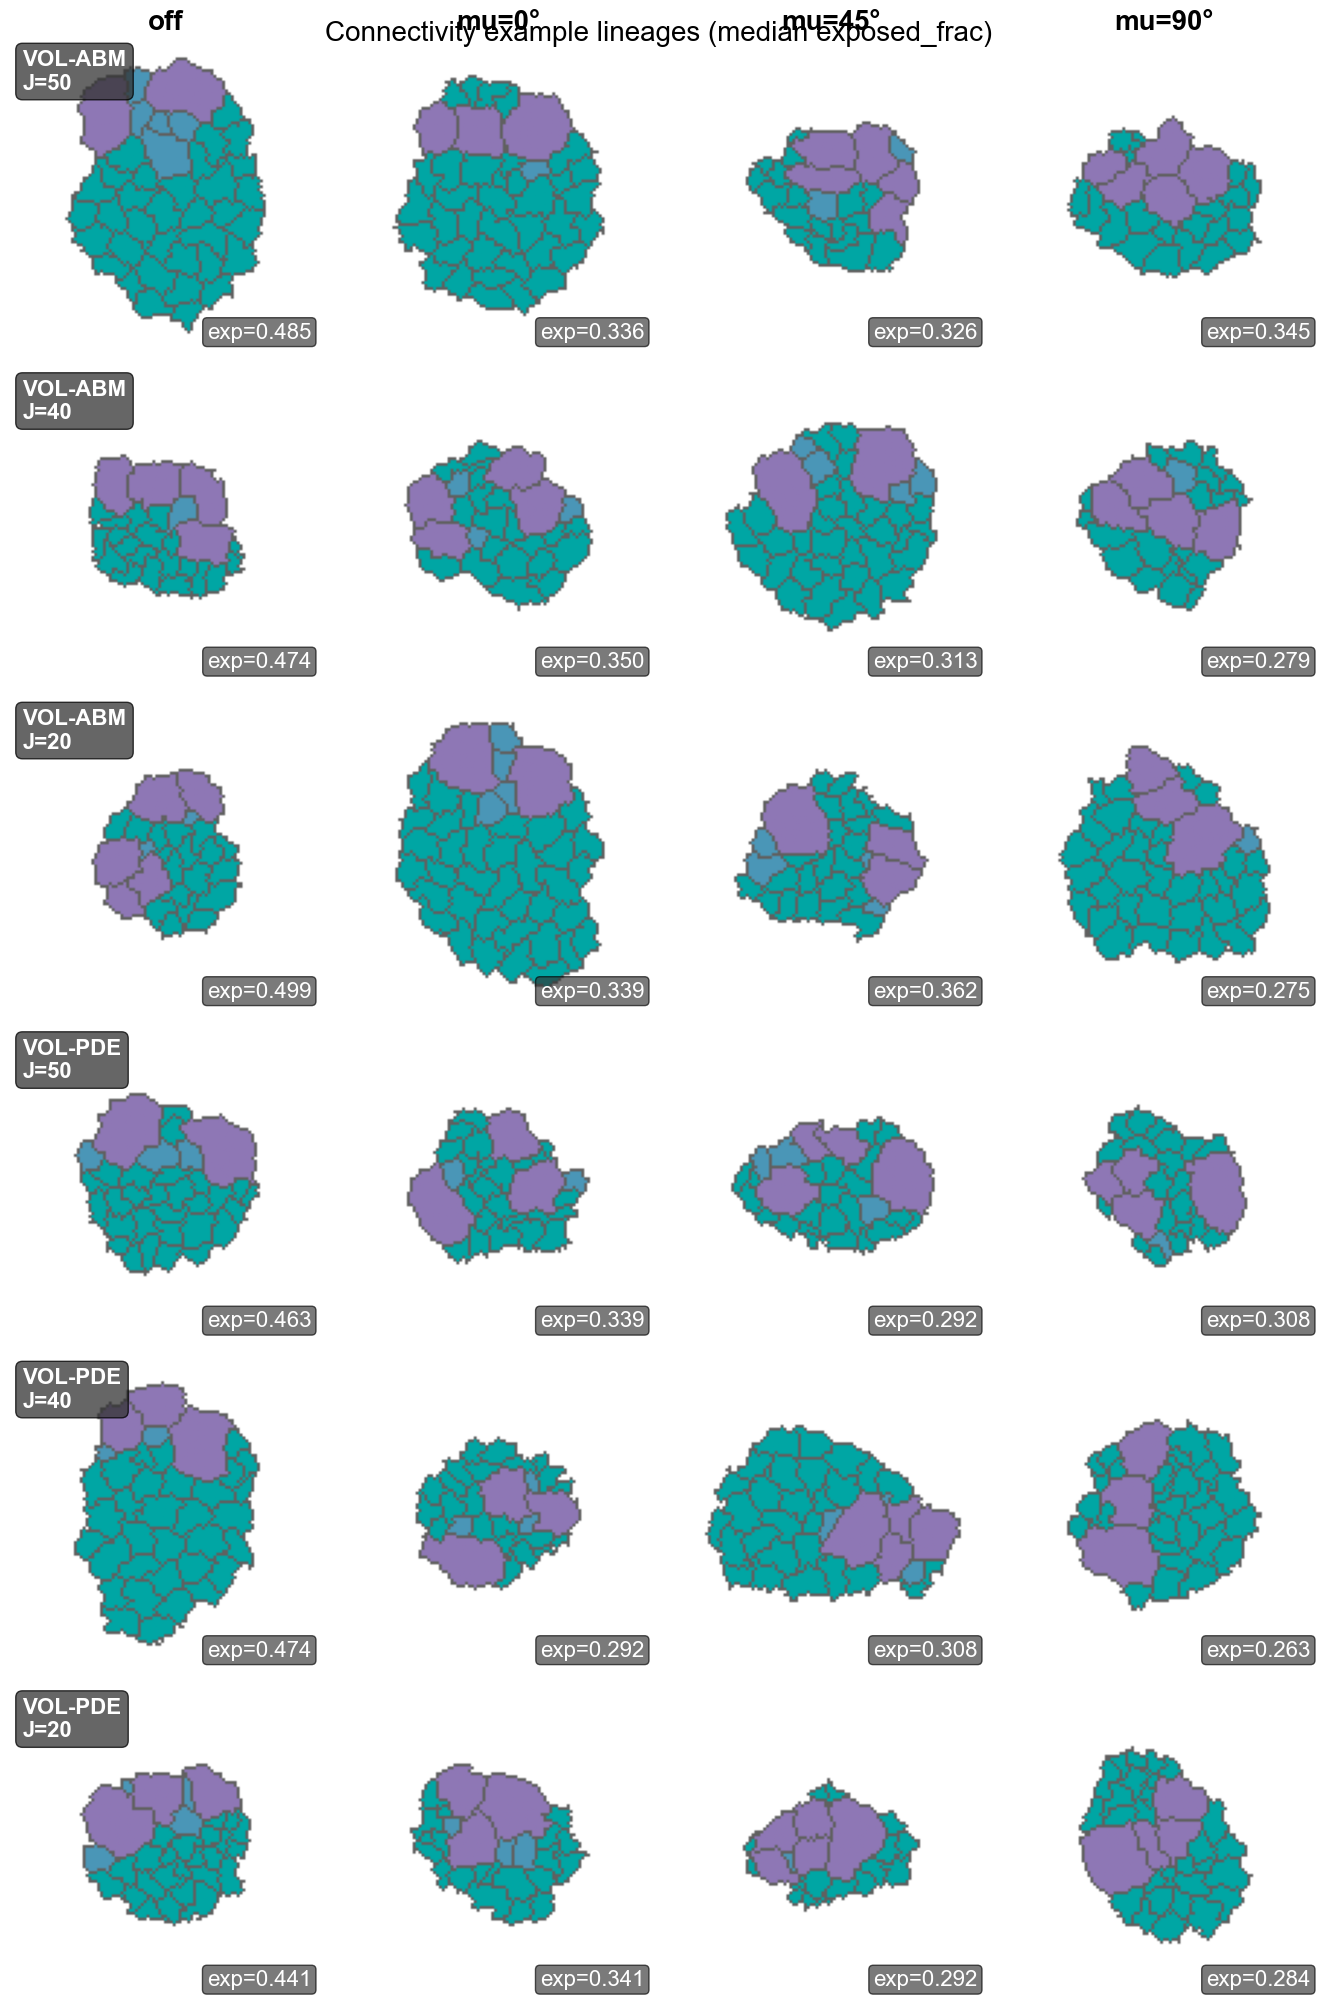

In [9]:
def panel_f() -> plt.Figure:
    # Re-use snapshots from panel_d (same metric: exposed_frac)
    keys = [(reg, adh, rl) for reg in REG_DYN_ORDER
            for adh in ADH_ORDER for rl in RELROT_ORDER]
    snapshots: dict[tuple, tuple] = {}
    for reg_dyn, adh, rl in keys:
        cond = _cond_name(adh, rl)
        geo, lmap, med = _load_median_run(cond, SIM_ID_MAP[reg_dyn], exp_df, "exposed_frac")
        snapshots[(reg_dyn, adh, rl)] = (geo, lmap, med)

    all_geos = [v[0] for v in snapshots.values() if v[0] is not None]
    target_size = uniform_crop_size(all_geos, pad=6)
    print(f"panel F uniform crop: {target_size}px")

    n_rows = len(REG_DYN_ORDER) * len(ADH_ORDER)
    n_cols = len(RELROT_ORDER)
    fig, axes = plt.subplots(n_rows, n_cols,
                              figsize=(3.4 * n_cols, 3.4 * n_rows),
                              squeeze=False)

    for ri_reg, reg_dyn in enumerate(REG_DYN_ORDER):
        for ri_adh, adh in enumerate(ADH_ORDER):
            row = ri_reg * len(ADH_ORDER) + ri_adh
            for ci, rl in enumerate(RELROT_ORDER):
                ax = axes[row, ci]
                geo, lmap, med = snapshots[(reg_dyn, adh, rl)]
                if geo is None:
                    ax.text(0.5, 0.5, "no data", ha="center", va="center",
                            transform=ax.transAxes)
                    ax.axis("off")
                    continue
                render_raw(crop_centered(geo, target_size),
                           label_map=crop_centered(lmap, target_size), ax=ax, title="")
                ax.axis("off")
                if row == 0:
                    ax.set_title(RELROT_LABELS[rl], fontsize=FONT_SIZE_TITLE,
                                  pad=8, fontweight="bold")
                if ci == 0:
                    ax.text(0.04, 0.97, f"{reg_dyn}\nJ={adh}",
                            transform=ax.transAxes, fontsize=FONT_SIZE_LABEL,
                            fontweight="bold", va="top", ha="left", color="white",
                            bbox=dict(boxstyle="round,pad=0.3", facecolor="#333333", alpha=0.75))
                if not np.isnan(med):
                    ax.text(0.97, 0.03, f"exp={med:.3f}", transform=ax.transAxes,
                            fontsize=FONT_SIZE_LABEL, va="bottom", ha="right", color="white",
                            bbox=dict(boxstyle="round,pad=0.2", facecolor="#333333", alpha=0.65))

    fig.suptitle("Connectivity example lineages (median exposed_frac)",
                  fontsize=FONT_SIZE_TITLE)
    fig.subplots_adjust(left=0.02, right=0.99, top=0.97, bottom=0.01,
                         wspace=0.04, hspace=0.06)
    return fig


fig_f = panel_f()
fig_f.savefig(FIG_DIR / "figure5_connectivity_lineages.png", bbox_inches="tight", facecolor="white")
fig_f.savefig(FIG_DIR / "figure5_connectivity_lineages.pdf", bbox_inches="tight", facecolor="white")
print("saved figure5_connectivity_lineages")
plt.show()
